## 1. Data Loading

In [83]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from matplotlib.pyplot import subplots
import matplotlib.pyplot as plt

In [84]:
df = pd.read_csv("../data/StudentPerformanceFactors.csv")
df.shape

(6607, 20)

In [85]:
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

## 2. Exploratory Data Analysis

### Missing Data Analysis

In [86]:
missing = df.isna().sum()
missing[missing > 0].sort_values(ascending=False)

Parental_Education_Level    90
Teacher_Quality             78
Distance_from_Home          67
dtype: int64

In [87]:
missing_table = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Proportion": (missing / len(df)).round(4),
    "Missing_%": (missing / len(df) * 100).round(2)
})

missing_table

,Missing_Count,Missing_Proportion,Missing_%
Hours_Studied,0,0.0000,0.00
Attendance,0,0.0000,0.00
Parental_Involvement,0,0.0000,0.00
Access_to_Resources,0,0.0000,0.00
Extracurricular_Activities,0,0.0000,0.00
Sleep_Hours,0,0.0000,0.00
Previous_Scores,0,0.0000,0.00
Motivation_Level,0,0.0000,0.00
Internet_Access,0,0.0000,0.00
Tutoring_Sessions,0,0.0000,0.00


In [88]:
df[["Parental_Education_Level", "Teacher_Quality", "Distance_from_Home"]].dtypes

Parental_Education_Level    object
Teacher_Quality             object
Distance_from_Home          object
dtype: object

The variables containing missing values are categorical (object type), suggesting that **mode imputation** is appropriate.

To further assess whether missingness is concentrated within specific observations, we examine the distribution of the number of missing values per row.

In [89]:
row_missing_count = df.isna().sum(axis=1)

row_missing_summary = (
    row_missing_count
        .value_counts()
        .sort_index()
        .to_frame(name="Count")
)

row_missing_summary["Proportion"] = (
    row_missing_summary["Count"] / len(df)
).round(4)

row_missing_summary["%"] = (
    row_missing_summary["Proportion"] * 100
).round(2)

row_missing_summary.index.name = "Missing"

row_missing_summary

,Count,Proportion,%
Missing,,,
0,6378,0.9653,96.53
1,223,0.0338,3.38
2,6,0.0009,0.09


The vast majority of observations (96.53%) contain no missing values, and only a negligible proportion (0.09%) contain multiple missing entries. This supports the use of simple imputation methods without substantial distortion of the dataset.

### Data Cleaning: Strategy Selection ***
Based on the analysis, we create two versions of the dataset to compare the impact of different missing data strategies on model generalisation.

In [90]:
# Dataset A: This remains the "Original" with NaNs (we will apply the "Loop Imputation" to its training split later)
df_imputed = df.copy()

# Dataset B: Dropped (Listwise Deletion)
df_dropped = df.dropna()

print(f"Imputed dataset shape: {df_imputed.shape}")
print(f"Dropped dataset shape: {df_dropped.shape}")

Imputed dataset shape: (6607, 20)
Dropped dataset shape: (6378, 20)


### Variable Types and Structure

In [91]:
df.dtypes

Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Disabilities         object
Parental_Education_Level      object
Distance_from_Home            object
Gender                        object
Exam_Score                     int64
dtype: object

The dataset consists of both numerical and categorical variables.

Numerical variables include `Hours_Studied`, `Attendance`, `Sleep_Hours`, `Previous_Scores`, `Tutoring_Sessions`, `Physical_Activity`, and `Exam_Score`.  

The remaining variables are categorical and will require encoding before model fitting.

### Distribution of the Target Variable

Text(0, 0.5, 'Frequency')

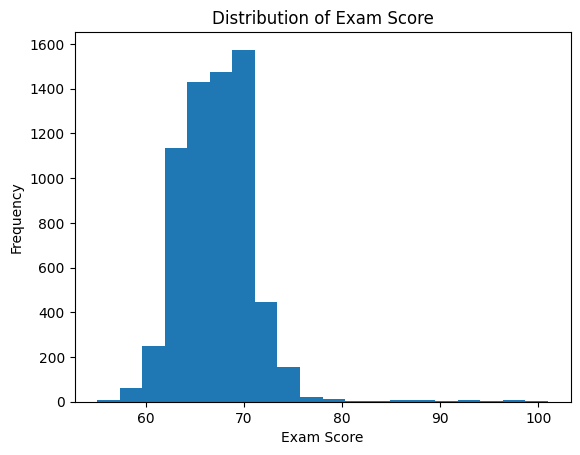

In [92]:
fig, ax = subplots()
ax.hist(df["Exam_Score"], bins=20)
ax.set_title("Distribution of Exam Score")
ax.set_xlabel("Exam Score")
ax.set_ylabel("Frequency")

The distribution of `Exam_Score` appears approximately bell-shaped and centred around 67, with slight right-skewness due to a small number of high-performing students scoring above 90. This suggests that linear regression may be appropriate as a first modelling approach.

### Summary Statistics (Numerical Variables)

In [93]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


The average `Exam_Score` is 67.24 with a standard deviation of 3.89, indicating relatively low dispersion. `Attendance`, `Hours_Studied` and `Previous_Scores` exhibit wider variation, suggesting potential predictive power.

### Correlation with Target ***
To quantify the linear relationships between the predictors and the final exam score, we calculate the correlation coefficients for both the original dataset (Dataset A) and the cleaned dataset (Dataset B).

In [94]:
df.corr(numeric_only=True)["Exam_Score"].sort_values()

Sleep_Hours         -0.017022
Physical_Activity    0.027824
Tutoring_Sessions    0.156525
Previous_Scores      0.175079
Hours_Studied        0.445455
Attendance           0.581072
Exam_Score           1.000000
Name: Exam_Score, dtype: float64

In [95]:
df_dropped.corr(numeric_only=True)["Exam_Score"].sort_values()

Sleep_Hours         -0.017171
Physical_Activity    0.025148
Tutoring_Sessions    0.156829
Previous_Scores      0.174283
Hours_Studied        0.445104
Attendance           0.580259
Exam_Score           1.000000
Name: Exam_Score, dtype: float64

In both datasets, `Attendance` and `Hours_Studied` show the strongest positive correlation with `Exam_Score`, with coefficients of approximately 0.58 and 0.45 respectively.

Variables such as `Sleep_Hours` and `Physical_Activity` exhibit negligible correlation with the target.

Comparing `df.corr()` with `df_dropped.corr()` reveals small shifts in these coefficients. These differences help justify the use of Dataset B for global regression, as the removal of incomplete observations may provide a more refined signal of the underlying linear trends.

## 3. Data Preprocessing ***

We now prepare both experimental tracks for modeling. This involves splitting the data, handling missing values for Track A, and encoding categorical variables for both.

In [96]:
TARGET = "Exam_Score"

### Dataset A: Training-Set Imputation

To ensure the integrity of our generalisation tests, we calculate the mode using only the training data and apply it to the test set.

In [97]:
X_a = df_imputed.drop(TARGET, axis=1)
y_a = df_imputed[TARGET]

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_a, y_a, test_size=0.2, random_state=42
)

# Mode Imputation (Loop Method; it prevents data leakage)
cat_missing = ["Parental_Education_Level", "Teacher_Quality", "Distance_from_Home"]

for col in cat_missing:
    mode_value = X_train_a[col].mode()[0]      
    X_train_a[col] = X_train_a[col].fillna(mode_value)
    X_test_a[col] = X_test_a[col].fillna(mode_value)

# Categorical Encoding
X_train_a_enc = pd.get_dummies(X_train_a, drop_first=True)
X_test_a_enc = pd.get_dummies(X_test_a, drop_first=True)

# Align train and test so they have the same columns
X_train_a_enc, X_test_a_enc = X_train_a_enc.align(X_test_a_enc, join="left", axis=1, fill_value=0)

### Dataset B: Listwise Deletion

Since Dataset B was already cleaned by dropping rows, we simply proceed with splitting and encoding.

In [98]:
X_b = df_dropped.drop(TARGET, axis=1)
y_b = df_dropped[TARGET]

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_b, y_b, test_size=0.2, random_state=42
)

# Categorical Encoding
X_train_b_enc = pd.get_dummies(X_train_b, drop_first=True)
X_test_b_enc = pd.get_dummies(X_test_b, drop_first=True)

In [99]:
# Check:
print(f"Track A columns: {len(X_train_a_enc.columns)}")
print(f"Track B columns: {len(X_train_b_enc.columns)}")

Track A columns: 27
Track B columns: 27


## 4. Global Regression models

### Fitting Multiple Linear Regression ***

We fit Multiple Linear Regression models to both experimental tracks to evaluate if the missing data handling strategy (Imputation vs. Deletion) significantly alters the model's coefficients or predictive performance.

#### Track A: Imputed Dataset

For Track A, missing categorical values were filled using the training-set mode (Loop Method) to preserve the original sample size of 6,607 observations while avoiding data leakage.

In [100]:
lr_a = LinearRegression()
lr_a.fit(X_train_a_enc, y_train_a)

# Initial Hold-out estimate
# Train-Test Evaluation for Track A
pred_train_a = lr_a.predict(X_train_a_enc)
pred_test_a = lr_a.predict(X_test_a_enc)
rmse_train_a = np.sqrt(mean_squared_error(y_train_a, pred_train_a))
rmse_test_a = np.sqrt(mean_squared_error(y_test_a, pred_test_a))

# Combine the cleaned and encoded training/test sets
X_full_a_enc = pd.concat([X_train_a_enc, X_test_a_enc]).reset_index(drop=True)
y_full_a = pd.concat([y_train_a, y_test_a]).reset_index(drop=True)

# 10-Fold Cross-Validation on combined cleaned data
cv_lr_a = cross_validate(lr_a, X_full_a_enc, y_full_a, cv=10, scoring="neg_root_mean_squared_error")
rmse_cv_a = -cv_lr_a["test_score"].mean()
std_cv_a = cv_lr_a["test_score"].std()

print(f"Track A - Training RMSE: {rmse_train_a:.2f}")
print(f"Track A - Test RMSE: {rmse_test_a:.2f}")

print(f"Track A - Hold-out RMSE: {rmse_test_a:.3f}")
print(f"Track A - CV Mean RMSE: {rmse_cv_a:.3f} (s.d. {std_cv_a:.3f})")


Track A - Training RMSE: 2.09
Track A - Test RMSE: 1.80
Track A - Hold-out RMSE: 1.804
Track A - CV Mean RMSE: 1.961 (s.d. 0.569)


#### Track B: Dropped Dataset (Listwise Deletion)

For Track B, observations containing missing values were removed, resulting in a dataset of 6,378 complete entries. This serves as a "pure data" baseline.

In [101]:
lr_b = LinearRegression()
lr_b.fit(X_train_b_enc, y_train_b)

# Initial Hold-out estimate
# Train-Test Evaluation for Track B
pred_train_b = lr_b.predict(X_train_b_enc)
pred_test_b = lr_b.predict(X_test_b_enc)
rmse_train_b = np.sqrt(mean_squared_error(y_train_b, pred_train_b))
rmse_test_b = np.sqrt(mean_squared_error(y_test_b, pred_test_b))

# Combine the encoded training/test sets for the dropped track
X_full_b_enc = pd.concat([X_train_b_enc, X_test_b_enc]).reset_index(drop=True)
y_full_b = pd.concat([y_train_b, y_test_b]).reset_index(drop=True)

# 10-Fold Cross-Validation on combined data
cv_lr_b = cross_validate(lr_b, X_full_b_enc, y_full_b, cv=10, scoring="neg_root_mean_squared_error")
rmse_cv_b = -cv_lr_b["test_score"].mean()
std_cv_b = cv_lr_b["test_score"].std()

print(f"Track B - Training RMSE: {rmse_train_b:.2f}")
print(f"Track B - Test RMSE: {rmse_test_b:.2f}")

print(f"Track B - Hold-out RMSE: {rmse_test_b:.3f}")
print(f"Track B - CV Mean RMSE: {rmse_cv_b:.3f} (s.d. {std_cv_b:.3f})")

Track B - Training RMSE: 2.07
Track B - Test RMSE: 2.04
Track B - Hold-out RMSE: 2.043
Track B - CV Mean RMSE: 2.049 (s.d. 0.330)


For both tracks, the training and test RMSE remain closely aligned (e.g., 2.09 vs 1.80 in Track A). This consistency suggests that our models are not overfitting and are successfully capturing the underlying signal within the data.

Track A (Imputed) achieved a lower 10-fold CV RMSE (1.961) compared to Track B (2.049). This suggests that retaining the full sample size through mode imputation preserves a stronger predictive signal.

Track B (Dropped) exhibited significantly lower variance, with a standard deviation of 0.330 compared to 0.569 for Track A. This indicates that listwise deletion, while slightly less accurate, produces a more consistent model across different data partitions.

While Track A offers better raw performance, Track B's higher stability and reliance on pure (non-synthetic) data make it a robust baseline for final model selection.

#### Diagnostic Plots

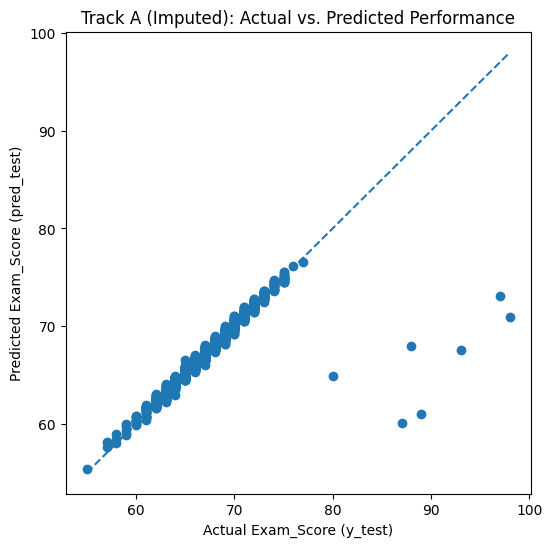

In [108]:
fig, ax = subplots(figsize=(6, 6))

ax.scatter(y_test_a, pred_test_a)
ax.set_xlabel("Actual Exam_Score (y_test)")
ax.set_ylabel("Predicted Exam_Score (pred_test)")
ax.set_title("Track A (Imputed): Actual vs. Predicted Performance")

# 45-degree line
minv = min(y_test_a.min(), pred_test_a.min())
maxv = max(y_test_a.max(), pred_test_a.max())
ax.plot([minv, maxv], [minv, maxv], '--')

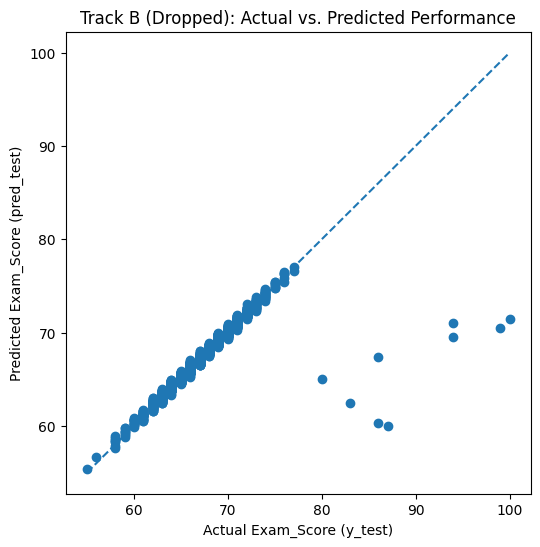

In [109]:
fig, ax = subplots(figsize=(6, 6))

ax.scatter(y_test_b, pred_test_b)
ax.set_xlabel("Actual Exam_Score (y_test)")
ax.set_ylabel("Predicted Exam_Score (pred_test)")
ax.set_title("Track B (Dropped): Actual vs. Predicted Performance")

# 45-degree line
minv = min(y_test_b.min(), pred_test_b.min())
maxv = max(y_test_b.max(), pred_test_b.max())
ax.plot([minv, maxv], [minv, maxv], '--')

Text(0.5, 1.0, 'Track A (Imputed): Prediction Error Analysis')

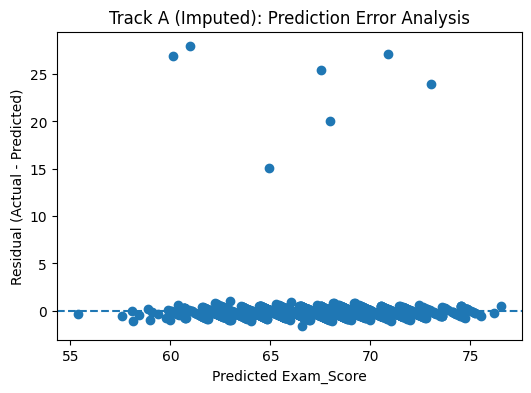

In [110]:
resid = y_test_a - pred_test_a

fig, ax = subplots(figsize=(6, 4))
ax.scatter(pred_test_a, resid)
ax.axhline(0, linestyle="--")
ax.set_xlabel("Predicted Exam_Score")
ax.set_ylabel("Residual (Actual - Predicted)")
ax.set_title("Track A (Imputed): Prediction Error Analysis")

Text(0.5, 1.0, 'Track B (Dropped): Prediction Error Analysis')

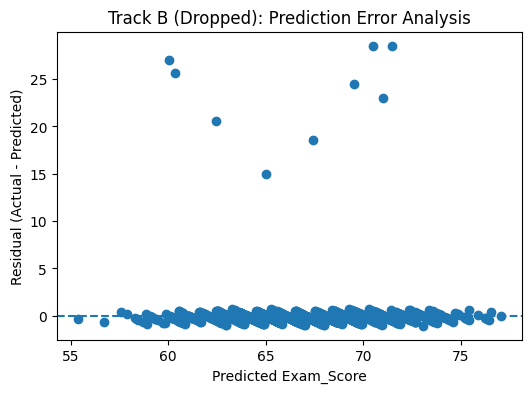

In [111]:
resid = y_test_b - pred_test_b

fig, ax = subplots(figsize=(6, 4))
ax.scatter(pred_test_b, resid)
ax.axhline(0, linestyle="--")
ax.set_xlabel("Predicted Exam_Score")
ax.set_ylabel("Residual (Actual - Predicted)")
ax.set_title("Track B (Dropped): Prediction Error Analysis")

In both tracks, the residual and "Actual vs. Predicted" plots show significant deviation for high exam scores. This confirms that the model systemically underpredicts top-performing students.

The diagnostic plots suggest that while the model performs well for mid-range scores, it tends to underpredict students with very high exam scores. This indicates potential model bias in the upper tail.

## 5. Tree-based Models


### Fitting Decision Tree Regressor

To capture potential non-linear relationships and feature interactions that a linear model may miss, we next fit a decision tree regressor. 

We use the same preprocessed design matrix (`X_train_enc`, `X_test_enc`) and target (`y_train`, `y_test`) as in the linear regression section.

#### Constrained tree (max_depth = 3)

We begin with a shallow tree to control model complexity and reduce overfitting.

In [335]:
tree_depth3 = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_depth3.fit(X_train_enc, y_train)

pred_train_tree3 = tree_depth3.predict(X_train_enc)
pred_test_tree3  = tree_depth3.predict(X_test_enc)

rmse_train_tree3 = np.sqrt(mean_squared_error(y_train, pred_train_tree3))
rmse_test_tree3  = np.sqrt(mean_squared_error(y_test,  pred_test_tree3))

rmse_train_tree3, rmse_test_tree3

(np.float64(2.9092390084283637), np.float64(2.729965999589966))

The training RMSE is close to the test RMSE, suggesting that the constrained tree does not suffer from severe overfitting. However, its test performance is worse than that of the linear model.

#### Unconstrained tree

We now remove the depth restriction to illustrate the high-variance behaviour of fully grown decision trees.

In [336]:
tree_full = DecisionTreeRegressor(random_state=42)
tree_full.fit(X_train_enc, y_train)

pred_train_full = tree_full.predict(X_train_enc)
pred_test_full  = tree_full.predict(X_test_enc)

rmse_train_full = np.sqrt(mean_squared_error(y_train, pred_train_full))
rmse_test_full  = np.sqrt(mean_squared_error(y_test,  pred_test_full))

rmse_train_full, rmse_test_full

(np.float64(0.0), np.float64(3.8343143737955696))

The unrestricted tree achieves zero training error, indicating complete memorisation of the training data. However, the test RMSE increases substantially, demonstrating severe overfitting. This highlights the high-variance nature of deep decision trees.

#### 10-Fold Cross-Validation

To obtain a more reliable estimate of generalisation performance, we perform 10-fold cross-validation on the full dataset.

In [337]:
X_full = pd.concat([X_train_enc, X_test_enc]).reset_index(drop=True)
y_full = pd.concat([y_train, y_test]).reset_index(drop=True)

cv = KFold(n_splits=10, shuffle=True, random_state=42)

cv_results_tree3 = cross_validate(
    DecisionTreeRegressor(max_depth=3, random_state=42),
    X_full,
    y_full,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    return_train_score=True
)

train_rmse_cv_tree3 = -cv_results_tree3["train_score"]
test_rmse_cv_tree3  = -cv_results_tree3["test_score"]

train_rmse_cv_tree3.mean(), test_rmse_cv_tree3.mean(), test_rmse_cv_tree3.std()

(np.float64(2.864785460433192),
 np.float64(2.8910280958879575),
 np.float64(0.3695221604901667))

The cross-validated test RMSE confirms that the decision tree performs worse than the linear model. This suggests that additional model flexibility does not improve predictive performance for this dataset.

## 6. 

### Model Comparison Table

In [305]:
comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree (depth = 3)",
        "Decision Tree (full)"
    ],
    "Test RMSE (hold-out)": [
        rmse_test,
        rmse_test_tree3,
        rmse_test_full
    ]
})

comparison_df.style.format({"Test RMSE (hold-out)": "{:.3f}"})

,Model,Test RMSE (hold-out)
0,Linear Regression,1.804
1,Decision Tree (depth = 3),2.730
2,Decision Tree (full),3.834


Overall, the linear regression model achieves the lowest test error.  
The shallow tree underperforms, while the fully grown tree severely overfits.  

These results illustrate the bias–variance trade-off: increasing model flexibility reduces bias but substantially increases variance, leading to poorer generalisation in this case.  

This suggests that the relationship between predictors and exam score is largely linear, and additional non-linear complexity is not justified by the data.

to do list for now: 
- drop the missing values instead of imputation (can give an argument about it since i have done imputation already)
- find the depth of the tree regression model that doesnt underfit (depth = 3) of overfit (depth = unrestricted) (the tutor suggested using RMSE vs depth graph but i dont know... is there anything about this in the intro to stat learning with python book?)
- average across the cross validation table instead of the single split test rmse in the Model Comparison table subsection, include the test rmse and the variance (prefer models with less precise and small variance than precise but large variance)
- fit random forest
- any other model?